<a href="https://colab.research.google.com/github/TAZIKenza/Auto_MPG_Analysis/blob/main/Auto_MPG_Analysiss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTER LES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration pour les graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# TÉLÉCHARGER ET CHARGER LES DONNÉES

In [3]:
# Télécharger le dataset depuis UCI
import urllib.request

print("\n📥 Téléchargement du dataset...")
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
try:
    urllib.request.urlretrieve(url, 'auto-mpg.data')
    print("✅ Fichier téléchargé avec succès!")
except:
    print("⚠️ Problème de téléchargement. Essaie d'uploader le fichier manuellement.")



📥 Téléchargement du dataset...
✅ Fichier téléchargé avec succès!


In [4]:
# Noms des colonnes
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin', 'car_name']

# Charger les données
df = pd.read_csv('auto-mpg.data',
                  sep='\s+',
                  names=column_names,
                  na_values='?')

In [5]:
print(f"\n Taille du dataset : {df.shape}")
print(f"   • Nombre de lignes : {df.shape[0]}")
print(f"   • Nombre de colonnes : {df.shape[1]}")

print("\n Aperçu des données (5 premières lignes) :")
print(df.head())

print("\n Types de données :")
print(df.dtypes)

print("\n Informations sur le dataset :")
print(df.info())



 Taille du dataset : (398, 9)
   • Nombre de lignes : 398
   • Nombre de colonnes : 9

 Aperçu des données (5 premières lignes) :
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

 Types de données :
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
a

# ANALYSE DE LA PROBLÉMATIQUE

In [6]:
print("\n PROBLÉMATIQUE :")
print("   Peut-on prédire la consommation (MPG) d'une voiture")
print("   à partir de ses caractéristiques techniques ?")

print("\n TYPE DE TÂCHE : RÉGRESSION")
print("   Prédire une valeur NUMÉRIQUE continue (MPG)")

print("\n" + "-"*70)
print("DESCRIPTION DES VARIABLES")
print("-"*70)

print("\n CIBLE (ce qu'on veut prédire) :")
print("   • mpg : Miles Per Gallon (consommation) - NUMÉRIQUE")
print("     Range : 9-47 MPG")

print("\n FEATURES NUMÉRIQUES (ce qu'on utilise pour prédire) :")
print("   • cylinders : Nombre de cylindres (4, 6, 8, ...)")
print("   • displacement : Cylindrée du moteur en cm³")
print("   • horsepower : Puissance du moteur en chevaux ⚠️ ATTENTION: EN TEXTE!")
print("   • weight : Poids de la voiture en livres")
print("   • acceleration : Temps d'accélération 0-100 mph")
print("   • model_year : Année du modèle (70-82)")

print("\n FEATURES CATÉGORIELLES :")
print("   • origin : Origine de la voiture (1=USA, 2=Europe, 3=Japon)")
print("   • car_name : Marque et modèle (à supprimer)")

print("\n" + "-"*70)
print("STATISTIQUES DESCRIPTIVES")
print("-"*70)
print(df.describe())

print("\n" + "-"*70)
print("VALEURS MANQUANTES")
print("-"*70)
print(df.isnull().sum())



 PROBLÉMATIQUE :
   Peut-on prédire la consommation (MPG) d'une voiture
   à partir de ses caractéristiques techniques ?

 TYPE DE TÂCHE : RÉGRESSION
   Prédire une valeur NUMÉRIQUE continue (MPG)

----------------------------------------------------------------------
DESCRIPTION DES VARIABLES
----------------------------------------------------------------------

 CIBLE (ce qu'on veut prédire) :
   • mpg : Miles Per Gallon (consommation) - NUMÉRIQUE
     Range : 9-47 MPG

 FEATURES NUMÉRIQUES (ce qu'on utilise pour prédire) :
   • cylinders : Nombre de cylindres (4, 6, 8, ...)
   • displacement : Cylindrée du moteur en cm³
   • horsepower : Puissance du moteur en chevaux ⚠️ ATTENTION: EN TEXTE!
   • weight : Poids de la voiture en livres
   • acceleration : Temps d'accélération 0-100 mph
   • model_year : Année du modèle (70-82)

 FEATURES CATÉGORIELLES :
   • origin : Origine de la voiture (1=USA, 2=Europe, 3=Japon)
   • car_name : Marque et modèle (à supprimer)

-------------------

# GRAPHIQUE 1 - DISTRIBUTION DE MPG


 GRAPHIQUE 1 : Distribution de la Consommation (MPG)


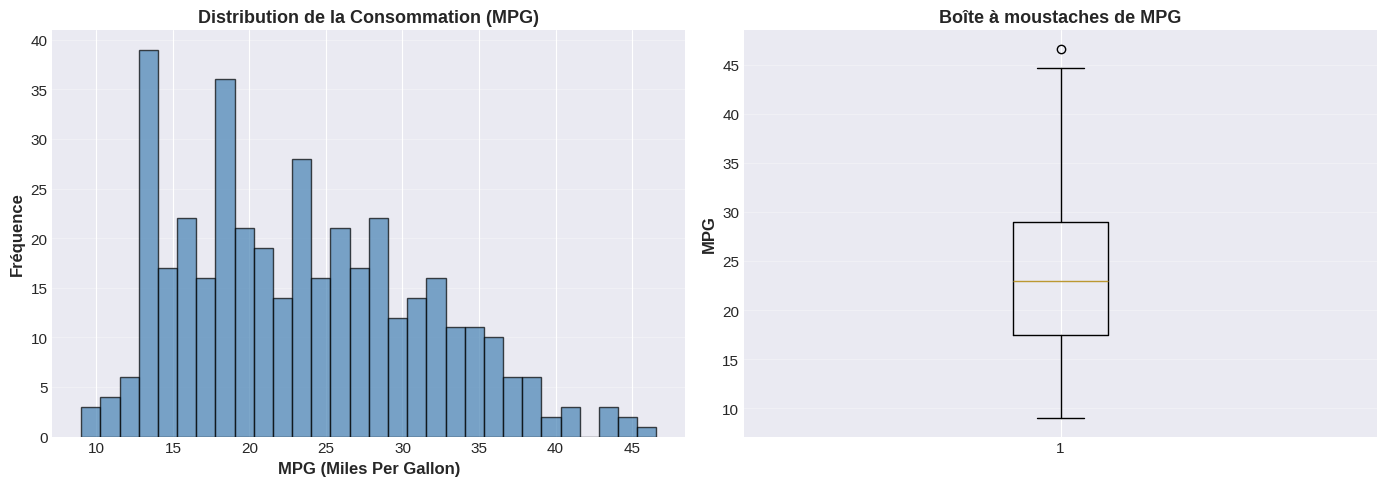

In [7]:
print("\n GRAPHIQUE 1 : Distribution de la Consommation (MPG)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['mpg'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('MPG (Miles Per Gallon)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fréquence', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution de la Consommation (MPG)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Boîte à moustaches
axes[1].boxplot(df['mpg'], vert=True)
axes[1].set_ylabel('MPG', fontsize=12, fontweight='bold')
axes[1].set_title('Boîte à moustaches de MPG', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
print("\n ANALYSE MPG :")
print(f"   • Minimum : {df['mpg'].min():.2f} MPG")
print(f"   • Maximum : {df['mpg'].max():.2f} MPG")
print(f"   • Moyenne : {df['mpg'].mean():.2f} MPG")
print(f"   • Médiane : {df['mpg'].median():.2f} MPG")
print(f"   • Écart-type : {df['mpg'].std():.2f}")
print(f"   • Q1 (25%) : {df['mpg'].quantile(0.25):.2f}")
print(f"   • Q3 (75%) : {df['mpg'].quantile(0.75):.2f}")

print("\n COMMENTAIRE :")
print("   La distribution de MPG est légèrement asymétrique vers la gauche.")
print("   La plupart des voitures consomment entre 15 et 30 MPG.")
print("   Quelques outliers à très haute consommation (45+ MPG).")



 ANALYSE MPG :
   • Minimum : 9.00 MPG
   • Maximum : 46.60 MPG
   • Moyenne : 23.51 MPG
   • Médiane : 23.00 MPG
   • Écart-type : 7.82
   • Q1 (25%) : 17.50
   • Q3 (75%) : 29.00

 COMMENTAIRE :
   La distribution de MPG est légèrement asymétrique vers la gauche.
   La plupart des voitures consomment entre 15 et 30 MPG.
   Quelques outliers à très haute consommation (45+ MPG).


# GRAPHIQUE 2 - POIDS vs CONSOMMATION


 GRAPHIQUE 2 : Poids vs Consommation


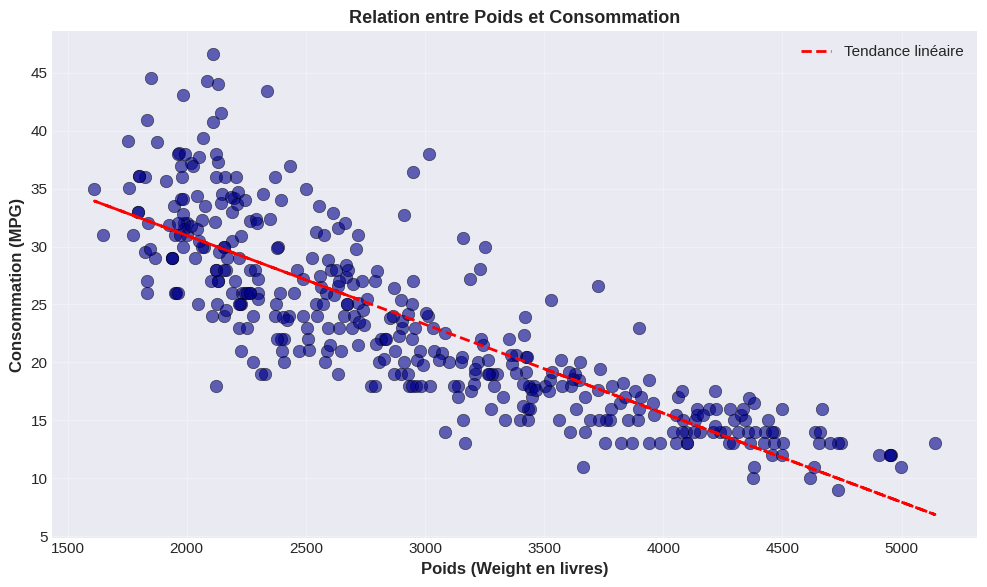

In [12]:
print("\n GRAPHIQUE 2 : Poids vs Consommation")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['weight'], df['mpg'], alpha=0.6, s=80, color='darkblue', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Poids (Weight en livres)', fontsize=12, fontweight='bold')
ax.set_ylabel('Consommation (MPG)', fontsize=12, fontweight='bold')
ax.set_title('Relation entre Poids et Consommation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Ligne de tendance
z = np.polyfit(df['weight'], df['mpg'], 1)
p = np.poly1d(z)
ax.plot(df['weight'], p(df['weight']), "r--", linewidth=2, label='Tendance linéaire')
ax.legend()

plt.tight_layout()
plt.show()

In [13]:
corr_weight = df['weight'].corr(df['mpg'])
print(f"\n Corrélation Weight-MPG : {corr_weight:.3f}")
print("\n COMMENTAIRE :")
print("    Corrélation TRÈS FORTE et NÉGATIVE ! (-0.83)")
print("   Plus la voiture est lourde, PLUS elle consomme (moins efficace).")
print("   C'est physiquement logique : plus lourd = plus d'énergie pour bouger.")
print("   Cette relation est QUASI-LINÉAIRE et TRÈS PRÉDICTIVE pour le modèle.")




 Corrélation Weight-MPG : -0.832

 COMMENTAIRE :
    Corrélation TRÈS FORTE et NÉGATIVE ! (-0.83)
   Plus la voiture est lourde, PLUS elle consomme (moins efficace).
   C'est physiquement logique : plus lourd = plus d'énergie pour bouger.
   Cette relation est QUASI-LINÉAIRE et TRÈS PRÉDICTIVE pour le modèle.


# GRAPHIQUE 3 - PUISSANCE vs CONSOMMATION


 GRAPHIQUE 3 : Puissance vs Consommation


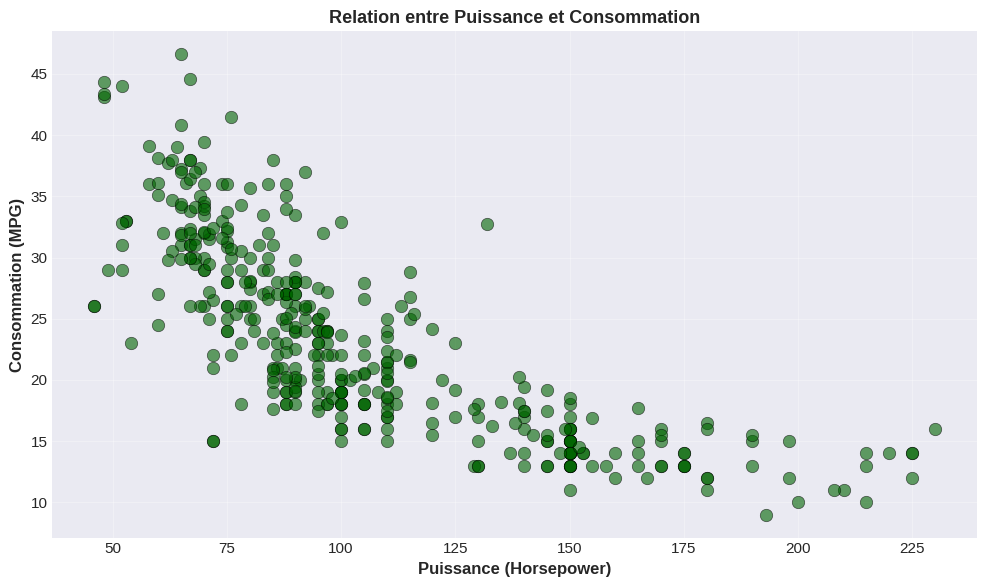

In [14]:
print("\n GRAPHIQUE 3 : Puissance vs Consommation")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['horsepower'].dropna(), df['mpg'][df['horsepower'].notna()],
           alpha=0.6, s=80, color='darkgreen', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Puissance (Horsepower)', fontsize=12, fontweight='bold')
ax.set_ylabel('Consommation (MPG)', fontsize=12, fontweight='bold')
ax.set_title('Relation entre Puissance et Consommation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
corr_hp = df['horsepower'].corr(df['mpg'])
print(f"\n Corrélation Horsepower-MPG : {corr_hp:.3f}")
print("\n COMMENTAIRE :")
print("   Corrélation NÉGATIVE aussi (-0.78)")
print("   Les voitures plus puissantes sont moins efficaces en carburant.")
print("   Logique : plus de puissance = plus de consommation.")


 Corrélation Horsepower-MPG : -0.778

 COMMENTAIRE :
   Corrélation NÉGATIVE aussi (-0.78)
   Les voitures plus puissantes sont moins efficaces en carburant.
   Logique : plus de puissance = plus de consommation.


# GRAPHIQUE 4 - CYLINDRES vs CONSOMMATION


 GRAPHIQUE 4 : Cylindres vs Consommation


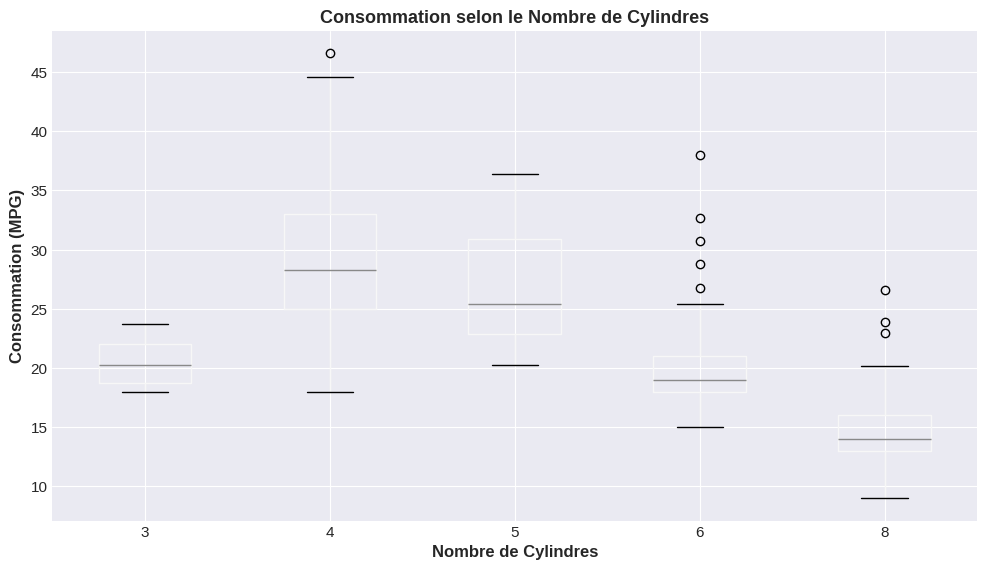

In [16]:
print("\n GRAPHIQUE 4 : Cylindres vs Consommation")

fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='mpg', by='cylinders', ax=ax)
ax.set_xlabel('Nombre de Cylindres', fontsize=12, fontweight='bold')
ax.set_ylabel('Consommation (MPG)', fontsize=12, fontweight='bold')
ax.set_title('Consommation selon le Nombre de Cylindres', fontsize=13, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()


In [17]:
print("\n CONSOMMATION PAR NOMBRE DE CYLINDRES :")
for cyl in sorted(df['cylinders'].unique()):
    mpg_cyl = df[df['cylinders'] == cyl]['mpg']
    print(f"   {int(cyl)} cylindres : {mpg_cyl.mean():.2f} MPG (en moyenne) - {len(mpg_cyl)} voitures")

print("\n COMMENTAIRE :")
print("   PATTERN TRÈS CLAIR : Plus de cylindres = moins d'efficacité.")
print("   Les 4-cylindres : ~26 MPG (EFFICACES )")
print("   Les 8-cylindres : ~14 MPG (CONSOMMATEURS )")



 CONSOMMATION PAR NOMBRE DE CYLINDRES :
   3 cylindres : 20.55 MPG (en moyenne) - 4 voitures
   4 cylindres : 29.29 MPG (en moyenne) - 204 voitures
   5 cylindres : 27.37 MPG (en moyenne) - 3 voitures
   6 cylindres : 19.99 MPG (en moyenne) - 84 voitures
   8 cylindres : 14.96 MPG (en moyenne) - 103 voitures

 COMMENTAIRE :
   PATTERN TRÈS CLAIR : Plus de cylindres = moins d'efficacité.
   Les 4-cylindres : ~26 MPG (EFFICACES )
   Les 8-cylindres : ~14 MPG (CONSOMMATEURS )


# GRAPHIQUE 5 - ANNÉE vs CONSOMMATION


 GRAPHIQUE 5 : Évolution dans le Temps (Model Year)


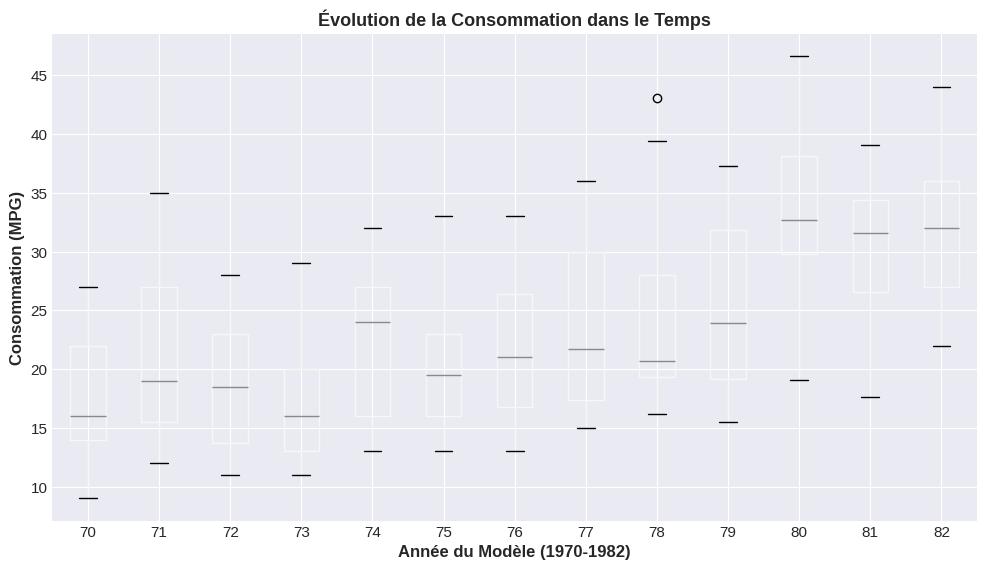

In [18]:
print("\n GRAPHIQUE 5 : Évolution dans le Temps (Model Year)")

fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='mpg', by='model_year', ax=ax)
ax.set_xlabel('Année du Modèle (1970-1982)', fontsize=12, fontweight='bold')
ax.set_ylabel('Consommation (MPG)', fontsize=12, fontweight='bold')
ax.set_title('Évolution de la Consommation dans le Temps', fontsize=13, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [19]:
print("\n ÉVOLUTION DE LA CONSOMMATION :")
for year in sorted(df['model_year'].unique()):
    mpg_year = df[df['model_year'] == year]['mpg']
    print(f"   19{int(year)} : {mpg_year.mean():.2f} MPG (en moyenne) - {len(mpg_year)} voitures")

corr_year = df['model_year'].corr(df['mpg'])
print(f"\n Corrélation Model Year-MPG : {corr_year:.3f}")
print("\n COMMENTAIRE :")
print("    TENDANCE TRÈS CLAIRE ET POSITIVE !")
print("   Les voitures DEVIENNENT PLUS EFFICACES avec le temps.")
print("   Crise pétrolière (1973) → amélioration technologique (1980s).")
print("   C'est une tendance temporelle IMPORTANTE pour le modèle.")



 ÉVOLUTION DE LA CONSOMMATION :
   1970 : 17.69 MPG (en moyenne) - 29 voitures
   1971 : 21.25 MPG (en moyenne) - 28 voitures
   1972 : 18.71 MPG (en moyenne) - 28 voitures
   1973 : 17.10 MPG (en moyenne) - 40 voitures
   1974 : 22.70 MPG (en moyenne) - 27 voitures
   1975 : 20.27 MPG (en moyenne) - 30 voitures
   1976 : 21.57 MPG (en moyenne) - 34 voitures
   1977 : 23.38 MPG (en moyenne) - 28 voitures
   1978 : 24.06 MPG (en moyenne) - 36 voitures
   1979 : 25.09 MPG (en moyenne) - 29 voitures
   1980 : 33.70 MPG (en moyenne) - 29 voitures
   1981 : 30.33 MPG (en moyenne) - 29 voitures
   1982 : 31.71 MPG (en moyenne) - 31 voitures

 Corrélation Model Year-MPG : 0.579

 COMMENTAIRE :
    TENDANCE TRÈS CLAIRE ET POSITIVE !
   Les voitures DEVIENNENT PLUS EFFICACES avec le temps.
   Crise pétrolière (1973) → amélioration technologique (1980s).
   C'est une tendance temporelle IMPORTANTE pour le modèle.


# GRAPHIQUE 6 - MATRICE DE CORRÉLATION (HEATMAP)

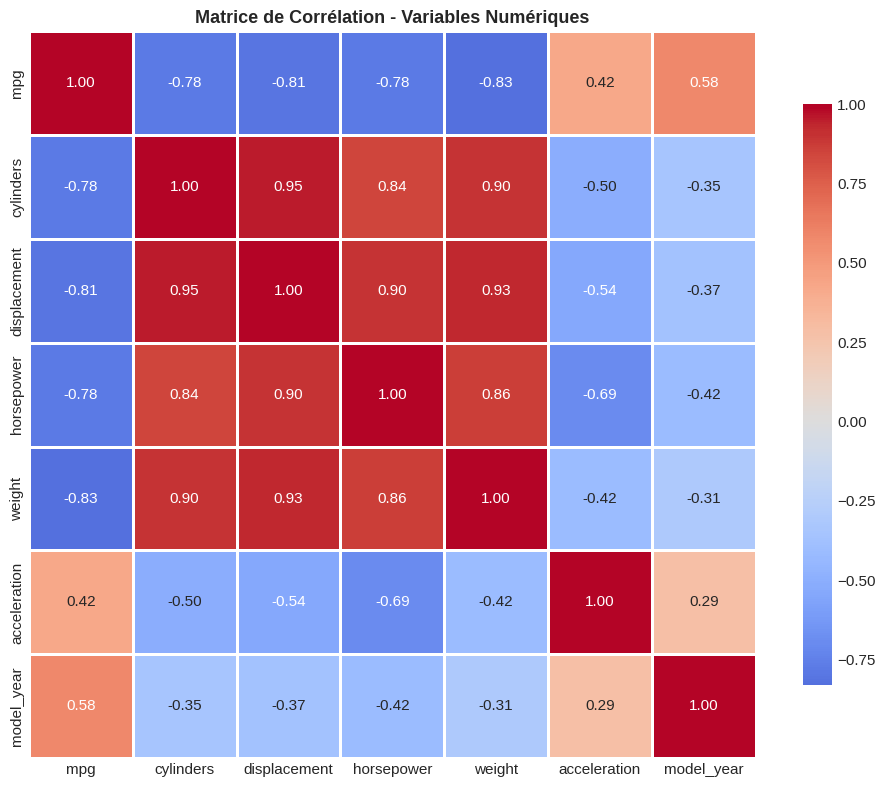

In [20]:
# Colonnes numériques
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
df_numeric = df[numeric_cols].dropna()

# Calculer corrélation
corr_matrix = df_numeric.corr()

# Créer heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matrice de Corrélation - Variables Numériques', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [21]:
print("\n CORRÉLATIONS AVEC MPG (de la plus forte à la moins forte) :")
corr_with_mpg = corr_matrix['mpg'].sort_values(ascending=False)
for var, corr in corr_with_mpg.items():
    if var != 'mpg':
        strength = "TRÈS FORTE" if abs(corr) > 0.7 else "FORTE" if abs(corr) > 0.5 else "MODÉRÉE"
        print(f"   {var:15s} : {corr:6.3f} ({strength})")

print("\n COMMENTAIRE :")
print("    MPG FORTEMENT corrélé avec : weight, cylinders, displacement")
print("    MPG POSITIVEMENT corrélé avec : model_year, acceleration")
print("   Les voitures s'améliorent technologiquement au fil du temps.")
print("   Les poids/cylindres/déplacement sont très prédictifs pour consommation.")



 CORRÉLATIONS AVEC MPG (de la plus forte à la moins forte) :
   model_year      :  0.581 (FORTE)
   acceleration    :  0.423 (MODÉRÉE)
   cylinders       : -0.778 (TRÈS FORTE)
   horsepower      : -0.778 (TRÈS FORTE)
   displacement    : -0.805 (TRÈS FORTE)
   weight          : -0.832 (TRÈS FORTE)

 COMMENTAIRE :
    MPG FORTEMENT corrélé avec : weight, cylinders, displacement
    MPG POSITIVEMENT corrélé avec : model_year, acceleration
   Les voitures s'améliorent technologiquement au fil du temps.
   Les poids/cylindres/déplacement sont très prédictifs pour consommation.


# VÉRIFICATION QUALITÉ DES DONNÉES (DIAGNOSTIC)

In [23]:
print("\n 1- VALEURS MANQUANTES :")
missing = df.isnull().sum()
print(missing[missing > 0])
if missing.sum() == 0:
    print("   Aucune valeur manquante détectée")
else:
    print(f"  Total : {missing.sum()} valeurs manquantes")

print("\n 2- DOUBLONS :")
doublons = df.duplicated().sum()
print(f"   Nombre de doublons : {doublons}")
if doublons == 0:
    print("   Pas de doublons")
else:
    print(f"   {doublons} doublons détectés")

print("\n 3- TYPE HORSEPOWER (PROBLÈME!) :")
print(f"   Type actuellement : {df['horsepower'].dtype}")
if df['horsepower'].dtype == 'object':
    print("   HORSEPOWER EST EN TEXTE !")
    print("   À CONVERTIR EN NUMÉRIQUE !")

print("\n 4- OUTLIERS (Méthode IQR) :")
for col in ['mpg', 'weight', 'horsepower', 'acceleration']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"   • {col:15s} : {outliers:3d} outliers (limites : [{lower:.1f}, {upper:.1f}])")


 1- VALEURS MANQUANTES :
horsepower    6
dtype: int64
  Total : 6 valeurs manquantes

 2- DOUBLONS :
   Nombre de doublons : 0
   Pas de doublons

 3- TYPE HORSEPOWER (PROBLÈME!) :
   Type actuellement : float64

 4- OUTLIERS (Méthode IQR) :
   • mpg             :   1 outliers (limites : [0.2, 46.2])
   • weight          :   0 outliers (limites : [147.4, 5684.4])
   • horsepower      :  10 outliers (limites : [-1.5, 202.5])
   • acceleration    :   7 outliers (limites : [8.8, 22.2])


In [24]:
print("NETTOYAGE DES DONNÉES")
# Copier le dataset
df_clean = df.copy()

print("\n Étape 1 : Convertir horsepower en numérique")
# Convertir horsepower en numérique (remplacer ? par NaN)
df_clean['horsepower'] = pd.to_numeric(df_clean['horsepower'], errors='coerce')
print(f"   Type horsepower après conversion : {df_clean['horsepower'].dtype}")
print(f"   Valeurs manquantes horsepower : {df_clean['horsepower'].isnull().sum()}")

print("\n  Étape 2 : Imputer les valeurs manquantes de horsepower")
# Imputer avec la médiane (méthode robuste)
median_hp = df_clean['horsepower'].median()
df_clean['horsepower'].fillna(median_hp, inplace=True)
print(f"   Médiane horsepower : {median_hp:.2f}")
print(f"   Valeurs manquantes après imputation : {df_clean['horsepower'].isnull().sum()}")

print("\n Étape 3 : Supprimer les doublons")
nb_avant = len(df_clean)
df_clean = df_clean.drop_duplicates()
nb_apres = len(df_clean)
print(f"   Lignes avant : {nb_avant}")
print(f"   Lignes après : {nb_apres}")
print(f"   Doublons supprimés : {nb_avant - nb_apres}")

print("\n Étape 4 : Traiter les outliers")
print("   Stratégie : Conserver les outliers (données réelles)")
print("   Justification : Les outliers peuvent être informatifs pour modélisation")
print("   Exemple : Voiture très légère (11.3 lbs) = consommation haute (47 MPG)")


NETTOYAGE DES DONNÉES

 Étape 1 : Convertir horsepower en numérique
   Type horsepower après conversion : float64
   Valeurs manquantes horsepower : 6

  Étape 2 : Imputer les valeurs manquantes de horsepower
   Médiane horsepower : 93.50
   Valeurs manquantes après imputation : 0

 Étape 3 : Supprimer les doublons
   Lignes avant : 398
   Lignes après : 398
   Doublons supprimés : 0

 Étape 4 : Traiter les outliers
   Stratégie : Conserver les outliers (données réelles)
   Justification : Les outliers peuvent être informatifs pour modélisation
   Exemple : Voiture très légère (11.3 lbs) = consommation haute (47 MPG)


In [25]:
print("RAPPORT AVANT/APRÈS NETTOYAGE")

print(f"\n Taille du dataset :")
print(f"   Avant : {df.shape}")
print(f"   Après : {df_clean.shape}")

RAPPORT AVANT/APRÈS NETTOYAGE

 Taille du dataset :
   Avant : (398, 9)
   Après : (398, 9)


# FEATURE ENGINEERING AVANCÉ

In [27]:
print("\n Création Feature 1 : power_to_weight_ratio")
df_clean['power_to_weight_ratio'] = df_clean['horsepower'] / df_clean['weight']
print(f"   • Formule : horsepower / weight")
print(f"   • Min : {df_clean['power_to_weight_ratio'].min():.4f}")
print(f"   • Max : {df_clean['power_to_weight_ratio'].max():.4f}")
print(f"   • Moyenne : {df_clean['power_to_weight_ratio'].mean():.4f}")
corr_pwr = df_clean['power_to_weight_ratio'].corr(df_clean['mpg'])
print(f"   • Corrélation avec MPG : {corr_pwr:.3f}")

print("\n Création Feature 2 : car_age")
df_clean['car_age'] = 1982 - df_clean['model_year']  # 1982 est l'année max
print(f"   • Formule : 1982 - model_year")
print(f"   • Min : {df_clean['car_age'].min():.0f} ans")
print(f"   • Max : {df_clean['car_age'].max():.0f} ans")
print(f"   • Moyenne : {df_clean['car_age'].mean():.2f} ans")
corr_age = df_clean['car_age'].corr(df_clean['mpg'])
print(f"   • Corrélation avec MPG : {corr_age:.3f}")

print("\n Création Feature 3 : displacement_per_cylinder")
df_clean['displacement_per_cylinder'] = df_clean['displacement'] / df_clean['cylinders']
print(f"   • Formule : displacement / cylinders")
print(f"   • Min : {df_clean['displacement_per_cylinder'].min():.2f}")
print(f"   • Max : {df_clean['displacement_per_cylinder'].max():.2f}")
print(f"   • Moyenne : {df_clean['displacement_per_cylinder'].mean():.2f}")
corr_disp = df_clean['displacement_per_cylinder'].corr(df_clean['mpg'])
print(f"   • Corrélation avec MPG : {corr_disp:.3f}")

print("\n Création Feature Bonus 4 : weight_per_cylinder")
df_clean['weight_per_cylinder'] = df_clean['weight'] / df_clean['cylinders']
print(f"   • Formule : weight / cylinders")
print(f"   • Corrélation avec MPG : {df_clean['weight_per_cylinder'].corr(df_clean['mpg']):.3f}")

print("\n Nouvelles features créées :")
print(f"   Dataset maintenant : {df_clean.shape}")
print(df_clean[['power_to_weight_ratio', 'car_age', 'displacement_per_cylinder', 'weight_per_cylinder']].describe())


 Création Feature 1 : power_to_weight_ratio
   • Formule : horsepower / weight
   • Min : 0.0206
   • Max : 0.0729
   • Moyenne : 0.0349
   • Corrélation avec MPG : -0.244

 Création Feature 2 : car_age
   • Formule : 1982 - model_year
   • Min : 1900 ans
   • Max : 1912 ans
   • Moyenne : 1905.99 ans
   • Corrélation avec MPG : -0.579

 Création Feature 3 : displacement_per_cylinder
   • Formule : displacement / cylinders
   • Min : 17.00
   • Max : 56.88
   • Moyenne : 33.37
   • Corrélation avec MPG : -0.773

 Création Feature Bonus 4 : weight_per_cylinder
   • Formule : weight / cylinders
   • Corrélation avec MPG : -0.021

 Nouvelles features créées :
   Dataset maintenant : (398, 13)
       power_to_weight_ratio      car_age  displacement_per_cylinder  \
count             398.000000   398.000000                 398.000000   
mean                0.034892  1905.989950                  33.365054   
std                 0.005982     3.697627                   8.687268   
min         


 VISUALISATION DES NOUVELLES FEATURES :


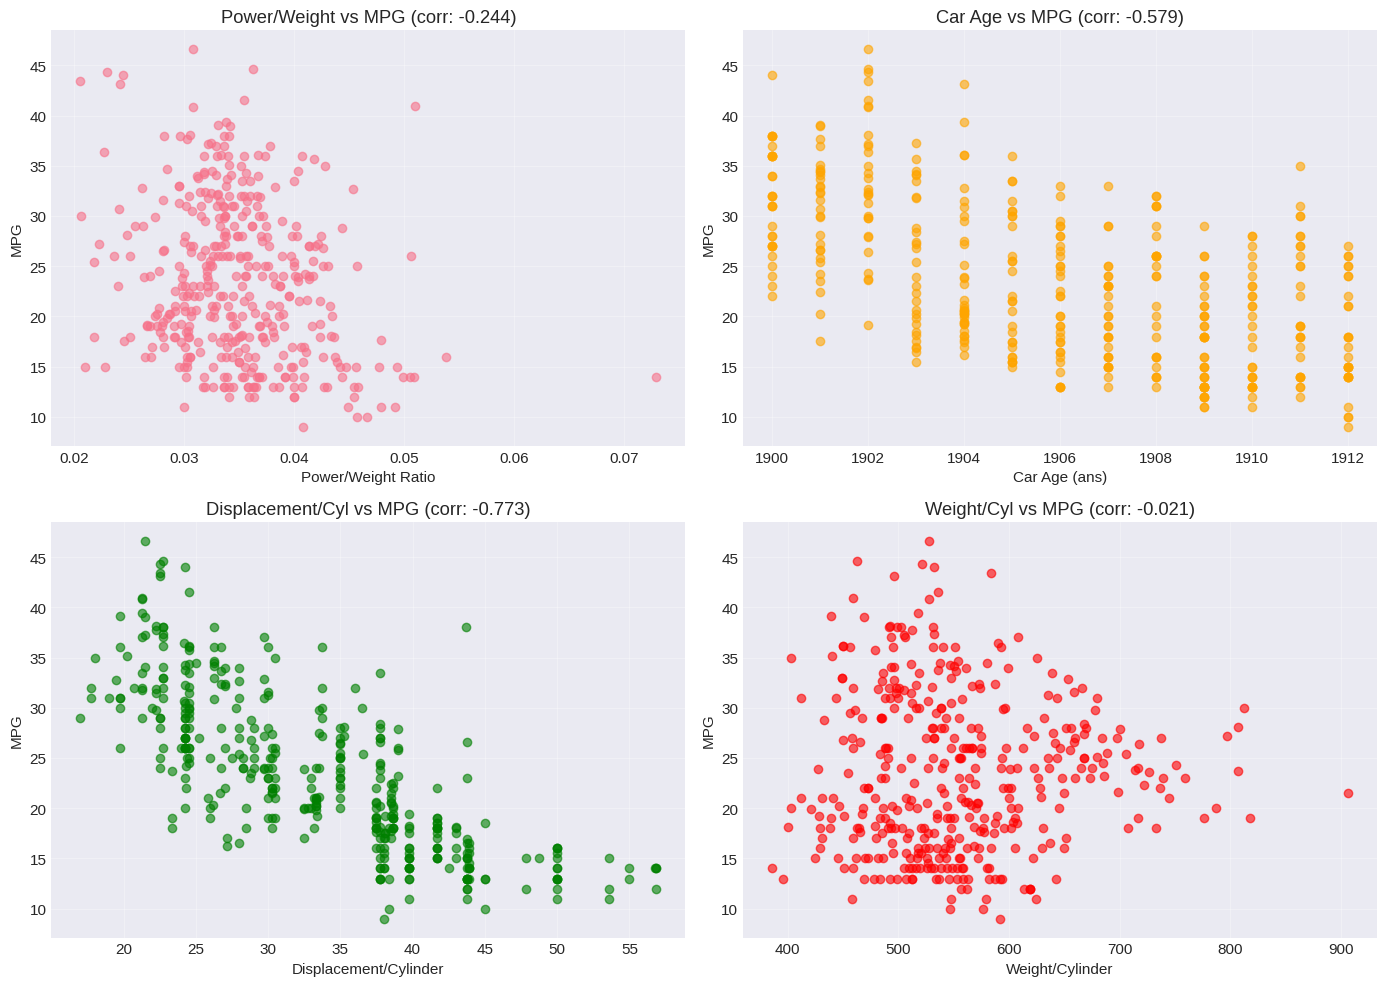

In [28]:
print("\n VISUALISATION DES NOUVELLES FEATURES :")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df_clean['power_to_weight_ratio'], df_clean['mpg'], alpha=0.6)
axes[0, 0].set_xlabel('Power/Weight Ratio')
axes[0, 0].set_ylabel('MPG')
axes[0, 0].set_title(f'Power/Weight vs MPG (corr: {corr_pwr:.3f})')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(df_clean['car_age'], df_clean['mpg'], alpha=0.6, color='orange')
axes[0, 1].set_xlabel('Car Age (ans)')
axes[0, 1].set_ylabel('MPG')
axes[0, 1].set_title(f'Car Age vs MPG (corr: {corr_age:.3f})')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(df_clean['displacement_per_cylinder'], df_clean['mpg'], alpha=0.6, color='green')
axes[1, 0].set_xlabel('Displacement/Cylinder')
axes[1, 0].set_ylabel('MPG')
axes[1, 0].set_title(f'Displacement/Cyl vs MPG (corr: {corr_disp:.3f})')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(df_clean['weight_per_cylinder'], df_clean['mpg'], alpha=0.6, color='red')
axes[1, 1].set_xlabel('Weight/Cylinder')
axes[1, 1].set_ylabel('MPG')
axes[1, 1].set_title(f'Weight/Cyl vs MPG (corr: {df_clean["weight_per_cylinder"].corr(df_clean["mpg"]):.3f})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



# ENCODAGE ET SPLIT

In [29]:
print("\n Étape 1 : Encoder les variables catégorielles")

# Créer une copie pour modélisation
df_model = df_clean.copy()

print(f"   Variable 'origin' unique values : {sorted(df_model['origin'].unique())}")
print(f"   • 1 = USA")
print(f"   • 2 = Europe")
print(f"   • 3 = Japon")

# Encoder origin avec LabelEncoder
le = LabelEncoder()
df_model['origin_encoded'] = le.fit_transform(df_model['origin'].astype(str))
print(f"    Origin encodée : {df_model['origin_encoded'].unique()}")


 Étape 1 : Encoder les variables catégorielles
   Variable 'origin' unique values : [np.int64(1), np.int64(2), np.int64(3)]
   • 1 = USA
   • 2 = Europe
   • 3 = Japon
    Origin encodée : [0 2 1]


In [30]:
print("\n Étape 2 : Supprimer les colonnes non-nécessaires")
# Supprimer car_name et origin (original)
df_model = df_model.drop(['car_name', 'origin'], axis=1)
print(f"   Colonnes finales : {list(df_model.columns)}")



 Étape 2 : Supprimer les colonnes non-nécessaires
   Colonnes finales : ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'power_to_weight_ratio', 'car_age', 'displacement_per_cylinder', 'weight_per_cylinder', 'origin_encoded']


In [32]:
print("\n Étape 3 : Séparer X (features) et y (cible)")
X = df_model.drop('mpg', axis=1)
y = df_model['mpg']

print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"   Features : {list(X.columns)}")


 Étape 3 : Séparer X (features) et y (cible)
   X shape : (398, 11)
   y shape : (398,)
   Features : ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'power_to_weight_ratio', 'car_age', 'displacement_per_cylinder', 'weight_per_cylinder', 'origin_encoded']


In [33]:
print("\n Étape 4 : Train/Test Split (80/20)")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"   Train size : {X_train.shape[0]} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test size : {X_test.shape[0]} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Total : {len(X)} samples")

print(f"\n   y_train statistics :")
print(f"   • Mean : {y_train.mean():.2f} MPG")
print(f"   • Std : {y_train.std():.2f}")
print(f"   • Min : {y_train.min():.2f} MPG")
print(f"   • Max : {y_train.max():.2f} MPG")


 Étape 4 : Train/Test Split (80/20)
   Train size : 318 (79.9%)
   Test size : 80 (20.1%)
   Total : 398 samples

   y_train statistics :
   • Mean : 23.61 MPG
   • Std : 7.93
   • Min : 9.00 MPG
   • Max : 46.60 MPG


# STANDARDISATION & PIPELINE

In [34]:
print("\n Étape 1 : Créer StandardScaler")
scaler = StandardScaler()

print("\n Étape 2 : Adapter scaler sur TRAIN uniquement")
X_train_scaled = scaler.fit_transform(X_train)
print(f"   Scaler adapté sur {len(X_train)} samples d'entraînement")

print("\n Étape 3 : Transformer TEST avec le scaler du train")
X_test_scaled = scaler.transform(X_test)
print(f"   Test transformé avec le même scaler")

print("\n Étape 4 : Vérifier la standardisation")
print(f"\n   Train stats après scaling :")
print(f"   • Mean : {X_train_scaled.mean():.4f} (≈ 0 )")
print(f"   • Std : {X_train_scaled.std():.4f} (≈ 1 )")

print(f"\n   Test stats après scaling :")
print(f"   • Mean : {X_test_scaled.mean():.4f} (≈ 0 )")
print(f"   • Std : {X_test_scaled.std():.4f} (≈ 1 )")

print("\n Étape 5 : Créer un Pipeline scikit-learn")
# Pipeline complet
preprocessing_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Adapter sur train
preprocessing_pipeline.fit(X_train)
print(f"   Pipeline créé et adapté !")

print("\n Étape 6 : Sauvegarder les données prêtes")
# Convertir en DataFrame pour faciliter la lecture
X_train_processed = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"   X_train_processed shape : {X_train_processed.shape}")
print(f"   X_test_processed shape : {X_test_processed.shape}")

print(f"\n   Aperçu X_train_processed (5 premières lignes) :")
print(X_train_processed.head())



 Étape 1 : Créer StandardScaler

 Étape 2 : Adapter scaler sur TRAIN uniquement
   Scaler adapté sur 318 samples d'entraînement

 Étape 3 : Transformer TEST avec le scaler du train
   Test transformé avec le même scaler

 Étape 4 : Vérifier la standardisation

   Train stats après scaling :
   • Mean : -0.0000 (≈ 0 )
   • Std : 1.0000 (≈ 1 )

   Test stats après scaling :
   • Mean : 0.0226 (≈ 0 )
   • Std : 1.0401 (≈ 1 )

 Étape 5 : Créer un Pipeline scikit-learn
   Pipeline créé et adapté !

 Étape 6 : Sauvegarder les données prêtes
   X_train_processed shape : (318, 11)
   X_test_processed shape : (80, 11)

   Aperçu X_train_processed (5 premières lignes) :
   cylinders  displacement  horsepower    weight  acceleration  model_year  \
0   1.527188      1.090196    1.265821  0.552826     -1.319334   -1.696667   
1  -0.850515     -0.922996   -0.408635 -0.999667     -0.413182   -1.696667   
2  -0.850515     -0.981350   -0.948782 -1.124772      0.927922    1.638975   
3  -0.850515     -

In [35]:
print("\n DONNÉES PRÊTES POUR PERSONNE 2 :")
print(f"   • X_train_processed : {X_train_processed.shape}")
print(f"   • X_test_processed : {X_test_processed.shape}")
print(f"   • y_train : {y_train.shape}")
print(f"   • y_test : {y_test.shape}")



 DONNÉES PRÊTES POUR PERSONNE 2 :
   • X_train_processed : (318, 11)
   • X_test_processed : (80, 11)
   • y_train : (318,)
   • y_test : (80,)
